# Sicred Asset Management
## Análise Exploratória das Carteiras

Notebook de análise dos dados gerados pelo pipeline ETL PySpark.  
Fonte: `carteira_flat.csv`

In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
import glob
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print('ok')

ok


In [2]:
#Configurações de estilo
plt.rcParams['figure.figsize']  = (14, 7)
plt.rcParams['font.family']     = 'DejaVu Sans'
plt.rcParams['axes.titlesize']  = 16
plt.rcParams['axes.labelsize']  = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

CORES = [
    '#2ecc71', '#3498db', '#e74c3c', '#f39c12',
    '#9b59b6', '#1abc9c', '#e67e22', '#34495e'
]

CORES_CLASSE = {
    'Renda Fixa':    '#3498db',
    'Renda Variavel':'#e74c3c',
}

CORES_RATING = {
    'AAA': '#2ecc71', 'AA+': '#27ae60', 'AA-': '#27ae60',
    'A+':  '#f39c12', 'BBB+':'#e67e22', 'NR':  '#95a5a6'
}

print('estilos configurados')

estilos configurados


---
## 1. Carregando os Dados

In [3]:
#Encontra o arquivo CSV
arquivos = glob.glob('../output/**/part-*.csv', recursive=True)

if not arquivos:
    raise FileNotFoundError('CSV nao encontrado. Rode: docker compose up etl')

arquivo = max(arquivos, key=os.path.getmtime)
print(f'arquivo: {arquivo}')

arquivo: ../output\carteira_flat_20260608_014506\part-00000-35cc0afa-660d-4f6a-8270-776601b3df11-c000.csv


In [4]:
#Carrega e plota o CSV
df = pd.read_csv(arquivo)
print(f'shape: {df.shape}')
df.head()

shape: (18, 19)


,data_posicao,cnpj_fundo,nome_fundo,tipo_fundo,codigo_ativo,nome_ativo,classe_ativo,indexador,data_vencimento,nome_emissor,cnpj_emissor,setor_emissor,rating_emissor,quantidade,preco_unitario,preco_mercado,valor_financeiro,percentual_pl,fonte_preco
0,2024-05-31,12.345.678/0001-90,Sicred RF Conservador FI,Renda Fixa,CDB-ITAU-2025,CDB Itau 120% CDI 2025,Renda Fixa,CDI,2025-12-01,Itau Unibanco Holding S.A.,60.872.504/0001-23,Financeiro,AA-,600.0,10245.60,10245.60,6147360.0,12.230,ANBIMA
1,2024-05-31,12.345.678/0001-90,Sicred RF Conservador FI,Renda Fixa,LFT-2027,Tesouro Selic 2027,Renda Fixa,SELIC,2027-09-01,Tesouro Nacional,00.394.460/0001-41,NaN,AAA,200.0,12456.78,12456.78,2491356.0,4.958,ANBIMA
2,2024-05-31,12.345.678/0001-90,Sicred RF Conservador FI,Renda Fixa,NTNB-2035,Tesouro IPCA+ 2035,Renda Fixa,IPCA,2035-05-15,Tesouro Nacional,00.394.460/0001-41,NaN,AAA,5000.0,3542.18,3542.18,17710900.0,35.250,ANBIMA
3,2024-05-31,12.345.678/0001-90,Sicred RF Conservador FI,Renda Fixa,NTNF-2031,Tesouro Prefixado 2031,Renda Fixa,Prefixado,2031-01-01,Tesouro Nacional,00.394.460/0001-41,NaN,AAA,8000.0,1089.54,1089.54,8716320.0,17.340,ANBIMA
4,2024-05-31,12.345.678/0001-90,Sicred RF Conservador FI,Renda Fixa,PETRDB-2028,Debenture Petrobras 2028,Renda Fixa,CDI,2028-06-15,Petroleo Brasileiro S.A. - Petrobras,33.000.167/0001-01,Energia,BBB+,15000.0,1023.45,1023.45,15351750.0,30.550,ANBIMA


In [5]:
#Converte os tipos para os graficos
df['data_posicao']     = pd.to_datetime(df['data_posicao'])
df['quantidade']       = pd.to_numeric(df['quantidade'],       errors='coerce')
df['preco_unitario']   = pd.to_numeric(df['preco_unitario'],   errors='coerce')
df['preco_mercado']    = pd.to_numeric(df['preco_mercado'],    errors='coerce')
df['valor_financeiro'] = pd.to_numeric(df['valor_financeiro'], errors='coerce')
df['percentual_pl']    = pd.to_numeric(df['percentual_pl'],    errors='coerce')

df.dtypes

data_posicao        datetime64[us]
cnpj_fundo                     str
nome_fundo                     str
tipo_fundo                     str
codigo_ativo                   str
nome_ativo                     str
classe_ativo                   str
indexador                      str
data_vencimento                str
nome_emissor                   str
cnpj_emissor                   str
setor_emissor                  str
rating_emissor                 str
quantidade                 float64
preco_unitario             float64
preco_mercado              float64
valor_financeiro           float64
percentual_pl              float64
fonte_preco                    str
dtype: object

---
## 2. Visão Geral

In [6]:
#Resumo geral
print(f'fundos:    {df["nome_fundo"].nunique()}')
print(f'ativos:    {df["codigo_ativo"].nunique()}')
print(f'emissores: {df["nome_emissor"].nunique()}')
print(f'data ref:  {df["data_posicao"].dt.date.unique()[0]}')
print(f'PL total:  R$ {df["valor_financeiro"].sum():,.2f}')

fundos:    4
ativos:    10
emissores: 6
data ref:  2024-05-31
PL total:  R$ 219,580,356.00


In [7]:
#PL por fundo
df.groupby('nome_fundo')['valor_financeiro'].sum().sort_values(ascending=False).to_frame('PL (R$)')

,PL (R$)
nome_fundo,
Sicred Previdencia PGBL FIE,90570630.0
Sicred RF Conservador FI,50417686.0
Sicred Acoes Brasil FIA,45025400.0
Sicred Multimercado Macro FIM,33566640.0


In [8]:
#Estatísticas descritivas
df[['preco_unitario', 'preco_mercado', 'valor_financeiro', 'percentual_pl']].describe().round(2)

,preco_unitario,preco_mercado,valor_financeiro,percentual_pl
count,18.00,18.00,18.00,18.00
mean,3306.87,3306.87,12198908.67,20.12
std,4629.67,4629.67,9211303.22,12.70
min,32.18,32.18,853400.00,1.90
25%,42.67,42.67,6167617.50,10.12
50%,1019.39,1019.39,9671430.00,18.05
75%,3542.18,3542.18,17121112.50,30.61
max,12456.78,12456.78,35421800.00,42.50


In [9]:
#Verifica nulos
nulos = df.isnull().sum()
nulos[nulos > 0] if nulos.sum() > 0 else print('sem nulos')

indexador        8
setor_emissor    6
dtype: int64

---
## 3. Composição das Carteiras por Fundo

In [10]:
#funcao auxiliar - nome fundo
def nome_curto(nome):
    return (nome
        .replace('SiCoop ', '')
        .replace(' FI', '')
        .replace(' FIM', '')
        .replace(' FIA', '')
        .replace(' FIE', '')
    )

fundos = df['nome_fundo'].unique()
for f in fundos:
    pl = df[df['nome_fundo'] == f]['valor_financeiro'].sum()
    n  = df[df['nome_fundo'] == f]['codigo_ativo'].nunique()
    print(f'{nome_curto(f)}: R$ {pl/1e6:.1f}M | {n} ativos')

Sicred RF Conservador: R$ 50.4M | 5 ativos
Sicred Multimercado MacroM: R$ 33.6M | 5 ativos
Sicred Acoes BrasilA: R$ 45.0M | 4 ativos
Sicred Previdencia PGBLE: R$ 90.6M | 4 ativos


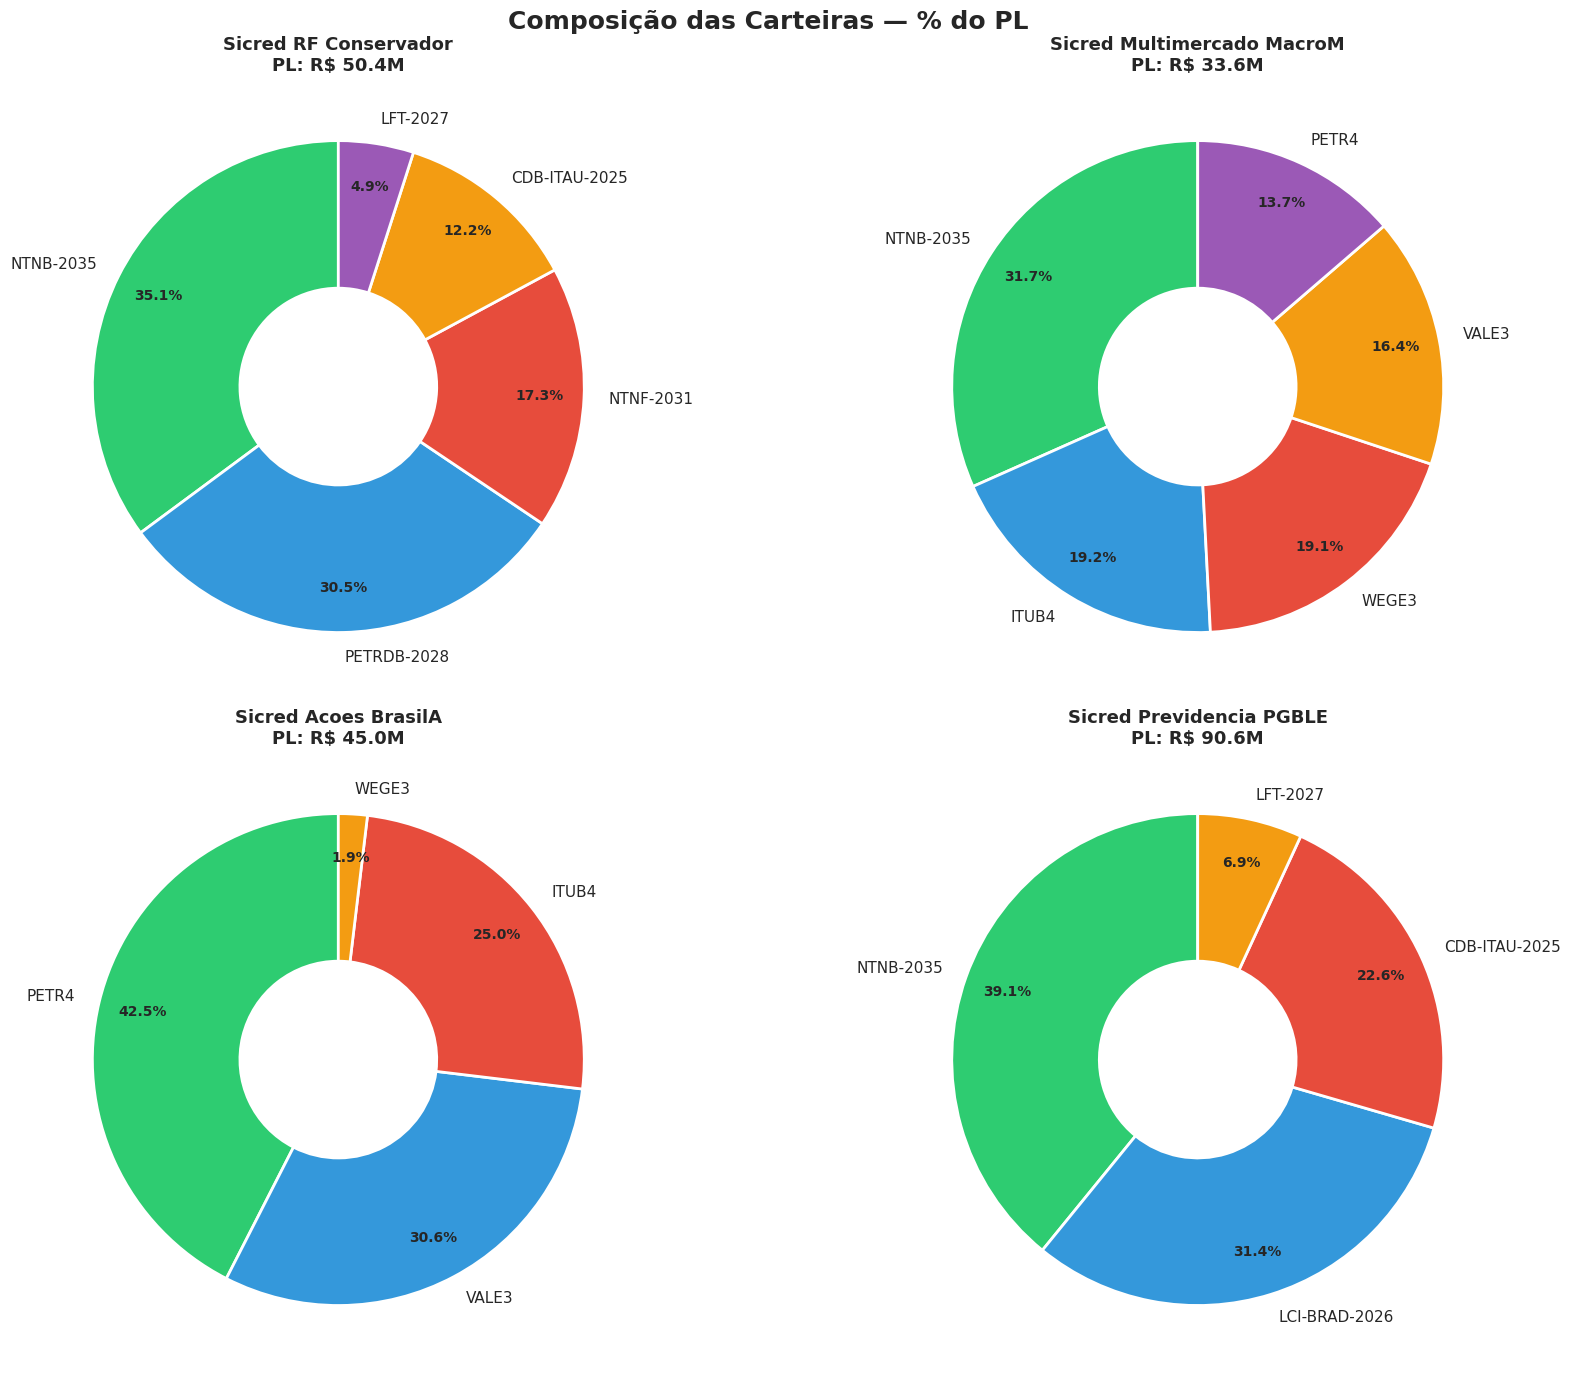

In [11]:
#Pizza por fundo
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

fig.suptitle('Composição das Carteiras — % do PL', fontsize=18, fontweight='bold')

for i, fundo in enumerate(fundos):
    ax   = axes[i]
    dad  = df[df['nome_fundo'] == fundo].sort_values('percentual_pl', ascending=False)
    pl   = dad['valor_financeiro'].sum()

    wedges, texts, autotexts = ax.pie(
        dad['percentual_pl'],
        labels=dad['codigo_ativo'],
        autopct='%1.1f%%',
        colors=CORES[:len(dad)],
        startangle=90,
        pctdistance=0.82,
        wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2)
    )
    for t in autotexts:
        t.set_fontsize(10)
        t.set_fontweight('bold')

    ax.set_title(f'{nome_curto(fundo)}\nPL: R$ {pl/1e6:.1f}M', fontsize=13, fontweight='bold')

for j in range(len(fundos), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

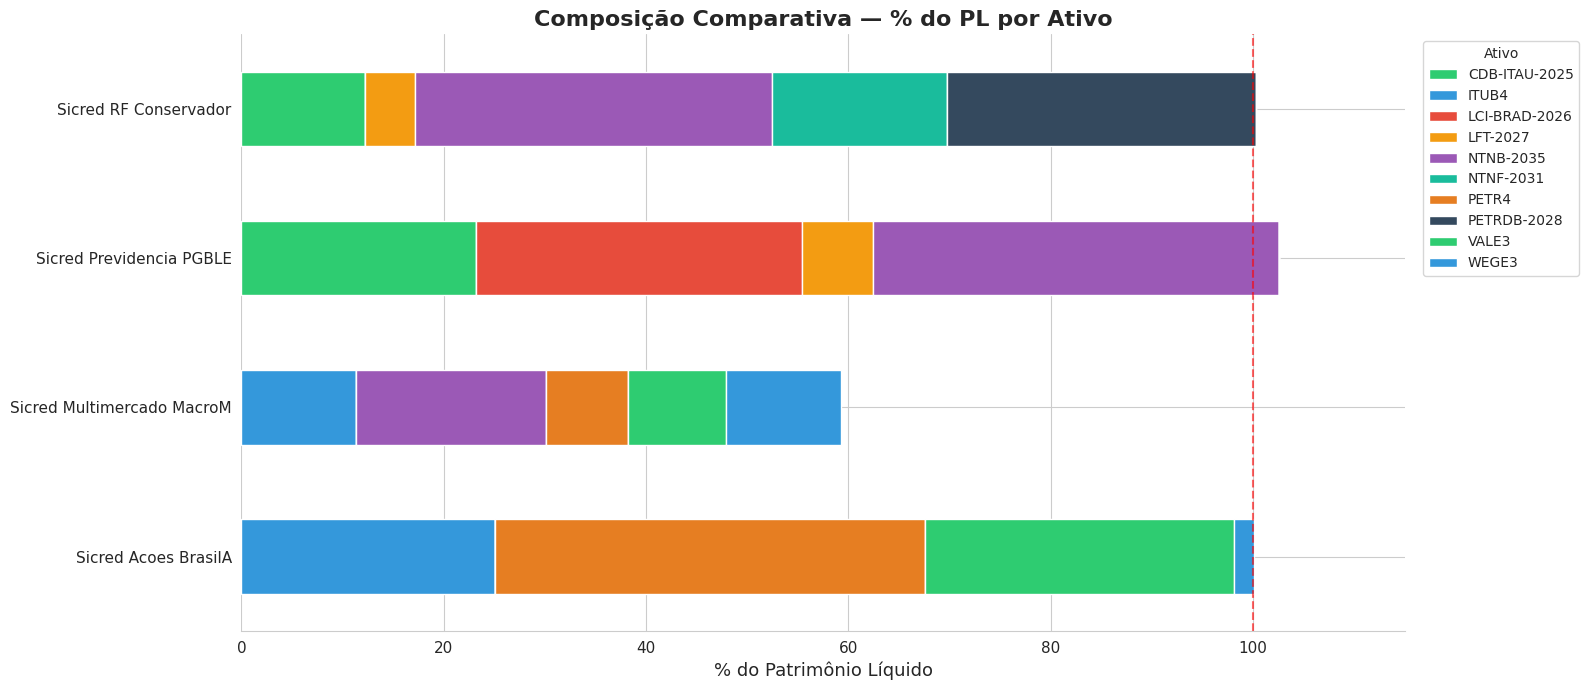

In [12]:
#barras por fundos
pivot = df.pivot_table(
    index='nome_fundo',
    columns='codigo_ativo',
    values='percentual_pl',
    aggfunc='sum',
    fill_value=0
)
pivot.index = [nome_curto(n) for n in pivot.index]

fig, ax = plt.subplots(figsize=(16, 7))
pivot.plot(kind='barh', stacked=True, ax=ax, color=CORES[:len(pivot.columns)], edgecolor='white')

ax.set_title('Composição Comparativa — % do PL por Ativo', fontsize=16, fontweight='bold')
ax.set_xlabel('% do Patrimônio Líquido')
ax.axvline(x=100, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
ax.set_xlim(0, 115)
ax.legend(title='Ativo', bbox_to_anchor=(1.01, 1), loc='upper left')
sns.despine(left=True)

plt.tight_layout()
plt.show()

---
## 4. Evolução de Preços dos Ativos

Como temos apenas uma data de posição, geramos uma série histórica simulada de 30 dias úteis com volatilidade realista por classe de ativo.

In [13]:
#Gera série histórica simulada
np.random.seed(42)

ativos_base = (
    df[['codigo_ativo', 'classe_ativo', 'preco_mercado']]
    .drop_duplicates('codigo_ativo')
    .dropna()
)

datas = pd.date_range(end='2024-05-31', periods=30, freq='B')

historico = []
for _, row in ativos_base.iterrows():
    vol = 0.008 if row['classe_ativo'] == 'Renda Fixa' else 0.022
    retornos = np.random.normal(0.0003, vol, len(datas))
    precos = [row['preco_mercado']]
    for r in reversed(retornos[1:]):
        precos.insert(0, precos[0] / (1 + r))
    for data, preco in zip(datas, precos):
        historico.append({
            'data': data,
            'codigo_ativo': row['codigo_ativo'],
            'classe_ativo': row['classe_ativo'],
            'preco': preco
        })

df_hist = pd.DataFrame(historico)
print(f'série gerada: {len(df_hist)} registros | {datas[0].date()} a {datas[-1].date()}')
df_hist.head()

série gerada: 300 registros | 2024-04-22 a 2024-05-31


,data,codigo_ativo,classe_ativo,preco
0,2024-04-22,CDB-ITAU-2025,Renda Fixa,10676.478338
1,2024-04-23,CDB-ITAU-2025,Renda Fixa,10667.871875
2,2024-04-24,CDB-ITAU-2025,Renda Fixa,10726.347904
3,2024-04-25,CDB-ITAU-2025,Renda Fixa,10860.258193
4,2024-04-26,CDB-ITAU-2025,Renda Fixa,10843.172542


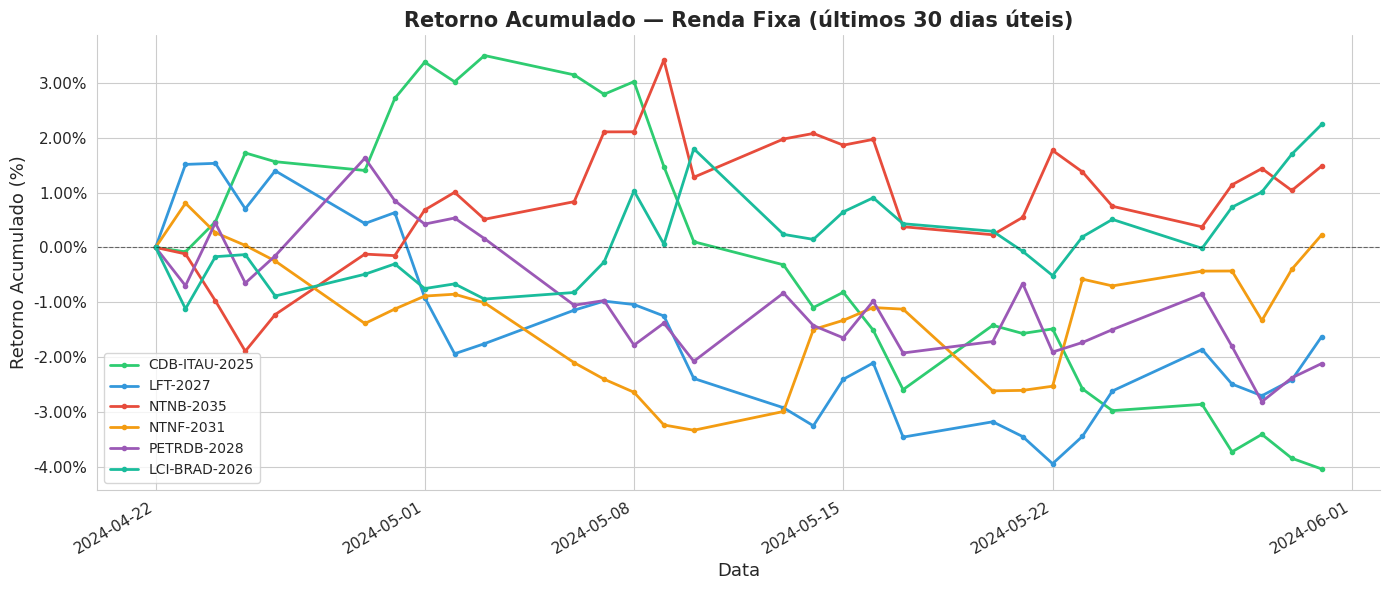

In [14]:
#Retorno acumulado renda fixa
fig, ax = plt.subplots(figsize=(14, 6))

dados_rf = df_hist[df_hist['classe_ativo'] == 'Renda Fixa']

for i, ativo in enumerate(dados_rf['codigo_ativo'].unique()):
    serie = dados_rf[dados_rf['codigo_ativo'] == ativo].copy()
    retorno = ((serie['preco'] / serie['preco'].iloc[0]) - 1) * 100
    ax.plot(serie['data'], retorno, label=ativo, color=CORES[i], linewidth=2, marker='o', markersize=3)

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Retorno Acumulado — Renda Fixa (últimos 30 dias úteis)', fontsize=15, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Retorno Acumulado (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
ax.legend(fontsize=10)
plt.xticks(rotation=30, ha='right')
sns.despine()

plt.tight_layout()
plt.show()

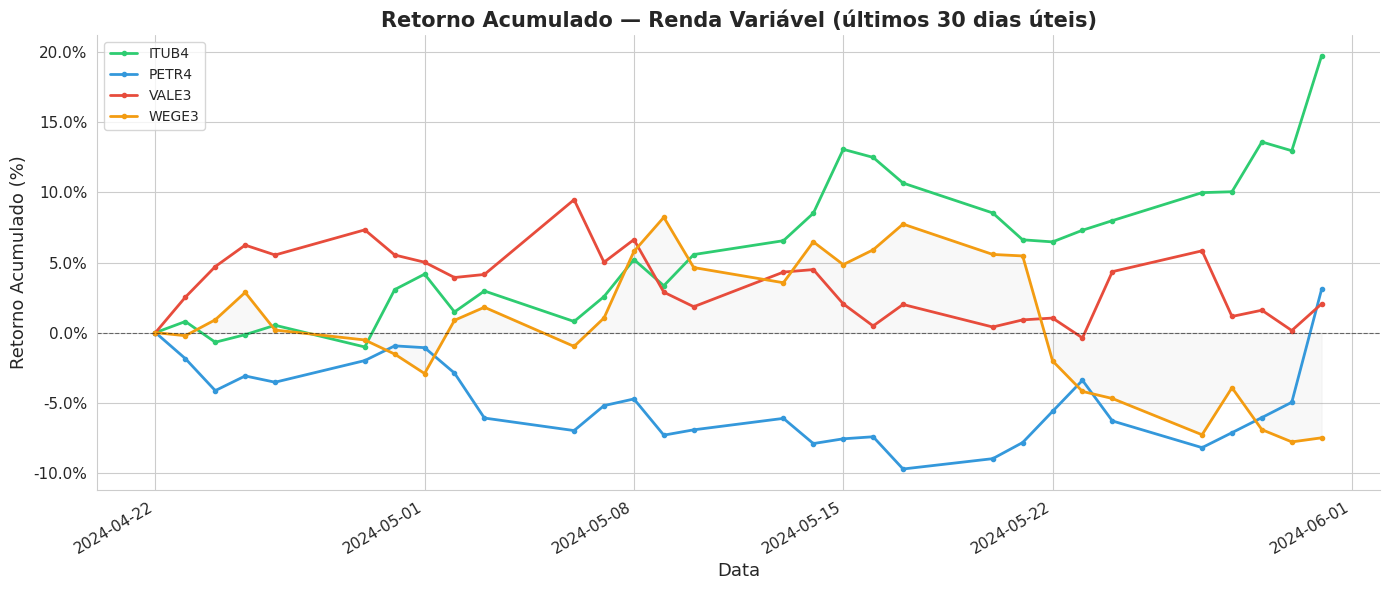

In [15]:
# Retorno acumulado renda variável
fig, ax = plt.subplots(figsize=(14, 6))

dados_rv = df_hist[df_hist['classe_ativo'] == 'Renda Variavel']

for i, ativo in enumerate(dados_rv['codigo_ativo'].unique()):
    serie = dados_rv[dados_rv['codigo_ativo'] == ativo].copy()
    retorno = ((serie['preco'] / serie['preco'].iloc[0]) - 1) * 100
    ax.plot(serie['data'], retorno, label=ativo, color=CORES[i], linewidth=2, marker='o', markersize=3)

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.fill_between(serie['data'], 0, retorno, alpha=0.05, color='gray')
ax.set_title('Retorno Acumulado — Renda Variável (últimos 30 dias úteis)', fontsize=15, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Retorno Acumulado (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(fontsize=10)
plt.xticks(rotation=30, ha='right')
sns.despine()

plt.tight_layout()
plt.show()

---
## 5. Exposição por Classe de Ativo e Indexador

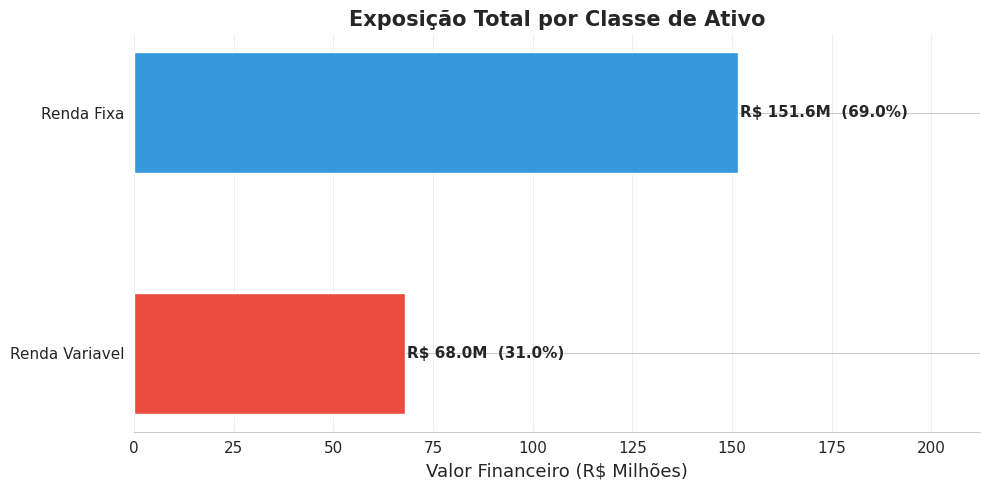

In [16]:
# Exposição por classe

expo_classe = df.groupby('classe_ativo')['valor_financeiro'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(expo_classe.index, expo_classe.values / 1e6,
               color=[CORES_CLASSE.get(c, '#95a5a6') for c in expo_classe.index],
               height=0.5, edgecolor='white')

for bar, val in zip(bars, expo_classe.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'R$ {val/1e6:.1f}M  ({val/expo_classe.sum()*100:.1f}%)',
            va='center', fontsize=11, fontweight='bold')

ax.set_title('Exposição Total por Classe de Ativo', fontsize=15, fontweight='bold')
ax.set_xlabel('Valor Financeiro (R$ Milhões)')
ax.set_xlim(0, expo_classe.max() / 1e6 * 1.4)
ax.grid(axis='x', alpha=0.3)
sns.despine(left=True)

plt.tight_layout()
plt.show()

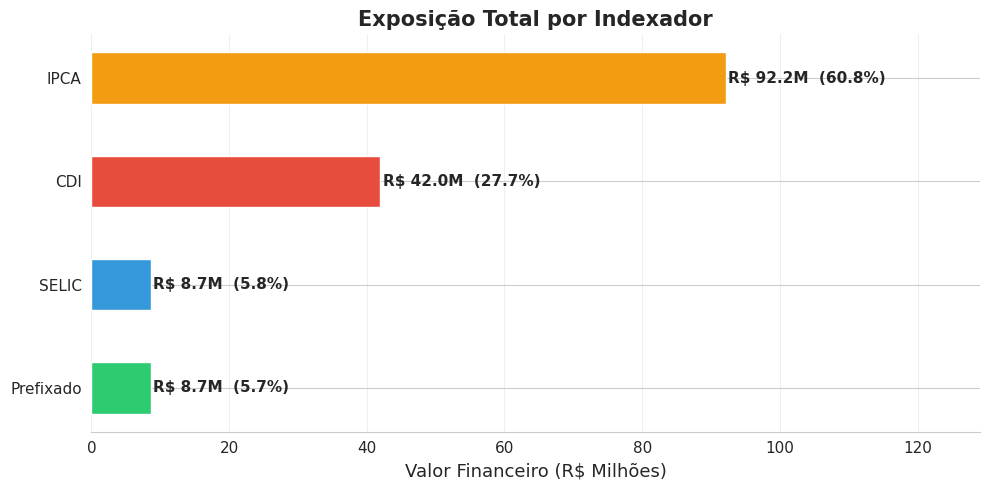

In [17]:
#Exposição por indexador
expo_idx = df.groupby('indexador')['valor_financeiro'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(expo_idx.index, expo_idx.values / 1e6,
               color=CORES[:len(expo_idx)], height=0.5, edgecolor='white')

for bar, val in zip(bars, expo_idx.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'R$ {val/1e6:.1f}M  ({val/expo_idx.sum()*100:.1f}%)',
            va='center', fontsize=11, fontweight='bold')

ax.set_title('Exposição Total por Indexador', fontsize=15, fontweight='bold')
ax.set_xlabel('Valor Financeiro (R$ Milhões)')
ax.set_xlim(0, expo_idx.max() / 1e6 * 1.4)
ax.grid(axis='x', alpha=0.3)
sns.despine(left=True)

plt.tight_layout()
plt.show()

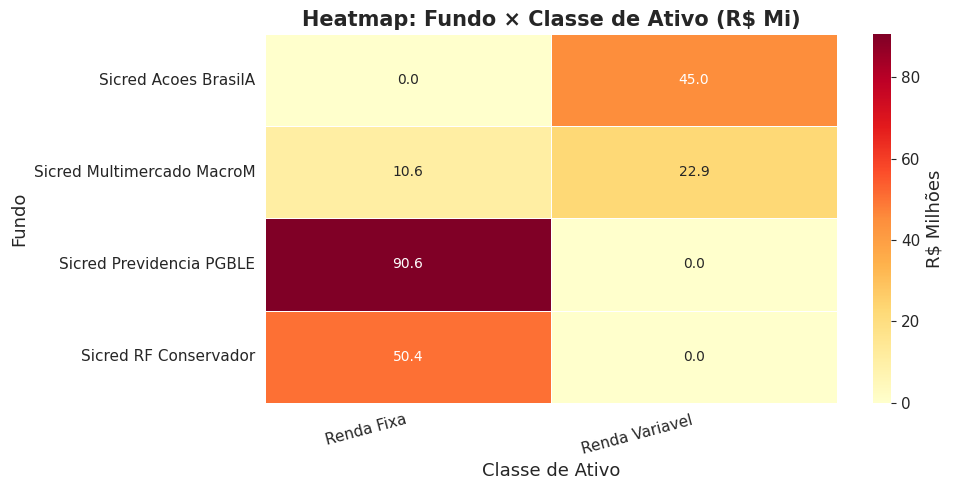

In [18]:
#Heatmap fundo x classe
pivot_heat = df.pivot_table(
    index='nome_fundo', columns='classe_ativo',
    values='valor_financeiro', aggfunc='sum', fill_value=0
) / 1e6
pivot_heat.index = [nome_curto(n) for n in pivot_heat.index]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_heat, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'R$ Milhões'})

ax.set_title('Heatmap: Fundo × Classe de Ativo (R$ Mi)', fontsize=15, fontweight='bold')
ax.set_xlabel('Classe de Ativo')
ax.set_ylabel('Fundo')
plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

---
## 6. Ranking de Ativos por Valor Financeiro

In [20]:
#Tabela de ranking
ranking = (
    df.groupby(['codigo_ativo', 'nome_ativo', 'classe_ativo'])
    .agg(valor_total=('valor_financeiro', 'sum'), n_fundos=('nome_fundo', 'nunique'))
    .reset_index()
    .sort_values('valor_total', ascending=False)
)
ranking['R$ Mi'] = (ranking['valor_total'] / 1e6).round(2)
ranking['% total'] = (ranking['valor_total'] / ranking['valor_total'].sum() * 100).round(2)
ranking.drop(columns='valor_total').reset_index(drop=True)

,codigo_ativo,nome_ativo,classe_ativo,n_fundos,R$ Mi,% total
0,NTNB-2035,Tesouro IPCA+ 2035,Renda Fixa,3,63.76,29.04
1,LCI-BRAD-2026,LCI Bradesco IPCA+1% 2026,Renda Fixa,1,28.43,12.95
2,CDB-ITAU-2025,CDB Itau 120% CDI 2025,Renda Fixa,2,26.64,12.13
3,PETR4,Petrobras PN,Renda Variavel,2,23.72,10.80
4,VALE3,Vale ON,Renda Variavel,2,19.30,8.79
5,ITUB4,Itau Unibanco PN,Renda Variavel,2,17.70,8.06
6,PETRDB-2028,Debenture Petrobras 2028,Renda Fixa,1,15.35,6.99
7,LFT-2027,Tesouro Selic 2027,Renda Fixa,2,8.72,3.97
8,NTNF-2031,Tesouro Prefixado 2031,Renda Fixa,1,8.72,3.97
9,WEGE3,WEG ON,Renda Variavel,2,7.25,3.30


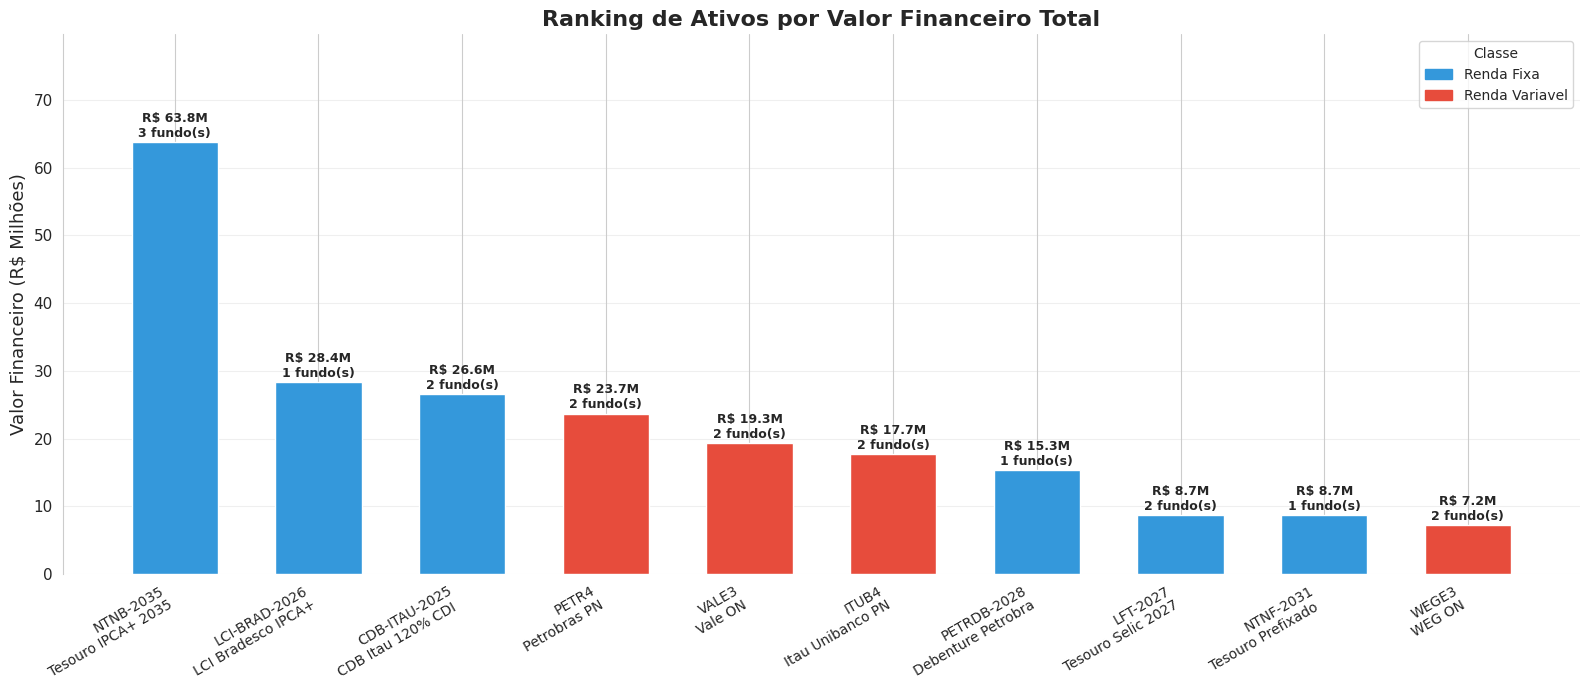

In [21]:
#Gráfico ranking
fig, ax = plt.subplots(figsize=(16, 7))

cores_barras = [CORES_CLASSE.get(c, '#95a5a6') for c in ranking['classe_ativo']]
bars = ax.bar(range(len(ranking)), ranking['valor_total'] / 1e6,
              color=cores_barras, edgecolor='white', linewidth=1, width=0.6)

for bar, row in zip(bars, ranking.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'R$ {row._6:.1f}M\n{row.n_fundos} fundo(s)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(ranking)))
ax.set_xticklabels(
    [f'{r.codigo_ativo}\n{r.nome_ativo[:18]}' for r in ranking.itertuples()],
    rotation=30, ha='right', fontsize=10
)
ax.set_title('Ranking de Ativos por Valor Financeiro Total', fontsize=16, fontweight='bold')
ax.set_ylabel('Valor Financeiro (R$ Milhões)')
ax.set_ylim(0, ranking['valor_total'].max() / 1e6 * 1.25)
ax.grid(axis='y', alpha=0.3)

legenda = [Patch(color=v, label=k) for k, v in CORES_CLASSE.items()]
ax.legend(handles=legenda, title='Classe', loc='upper right')
sns.despine(bottom=True)

plt.tight_layout()
plt.show()

---
## 7. Distribuição do PL por Emissor

In [22]:
#Tabela por emissor
por_emissor = (
    df.groupby(['nome_emissor', 'setor_emissor', 'rating_emissor'])
    .agg(valor_total=('valor_financeiro', 'sum'),
         n_ativos=('codigo_ativo', 'nunique'),
         n_fundos=('nome_fundo', 'nunique'))
    .reset_index()
    .sort_values('valor_total', ascending=False)
)
por_emissor['R$ Mi']    = (por_emissor['valor_total'] / 1e6).round(2)
por_emissor['% total']  = (por_emissor['valor_total'] / por_emissor['valor_total'].sum() * 100).round(2)
por_emissor['% acum']   = por_emissor['% total'].cumsum().round(2)

por_emissor.drop(columns='valor_total').reset_index(drop=True)

,nome_emissor,setor_emissor,rating_emissor,n_ativos,n_fundos,R$ Mi,% total,% acum
0,Itau Unibanco Holding S.A.,Financeiro,AA-,2,4,44.34,32.04,32.04
1,Petroleo Brasileiro S.A. - Petrobras,Energia,BBB+,2,3,39.07,28.23,60.27
2,Banco Bradesco S.A.,Financeiro,AA-,1,1,28.43,20.54,80.81
3,Vale S.A.,Mineracao,BBB+,1,2,19.30,13.94,94.75
4,WEG S.A.,Industrial,A+,1,2,7.25,5.24,99.99


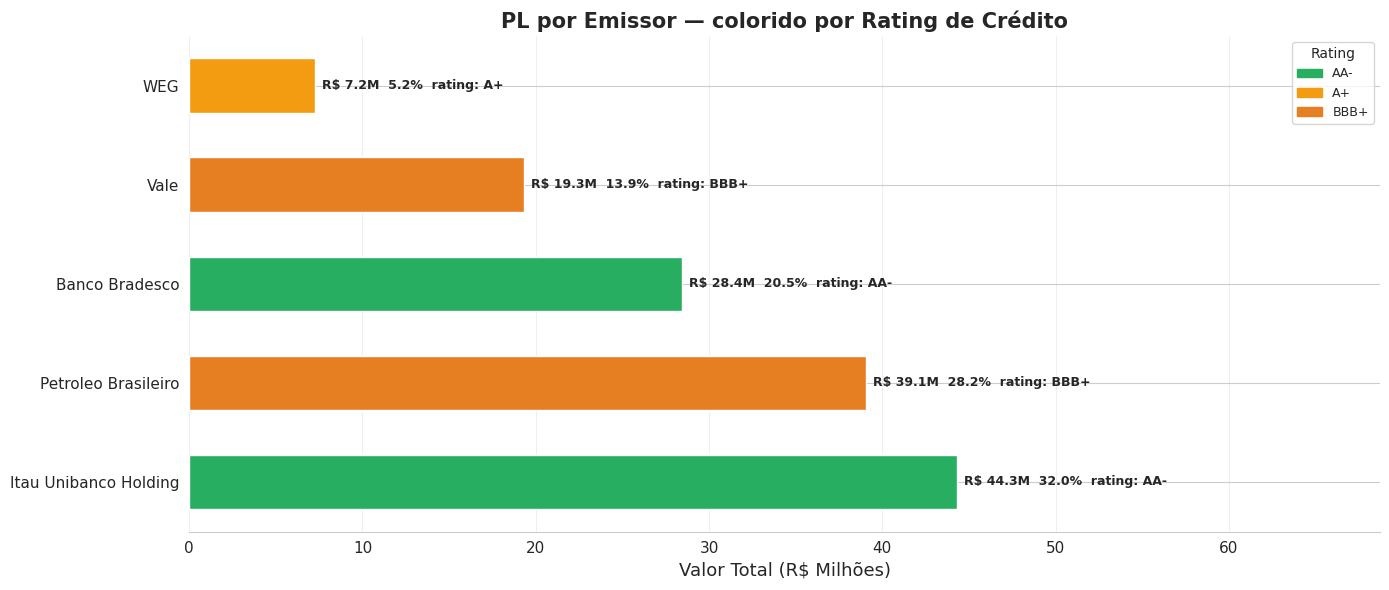

In [23]:
nomes_curtos_emit = [n.split(' S.A.')[0].split(' -')[0][:22] for n in por_emissor['nome_emissor']]
cores_emit = [CORES_RATING.get(r, '#95a5a6') for r in por_emissor['rating_emissor']]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(nomes_curtos_emit, por_emissor['valor_total'] / 1e6,
               color=cores_emit, height=0.55, edgecolor='white')

for bar, row in zip(bars, por_emissor.itertuples()):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
            f'R$ {row._7:.1f}M  {row._8:.1f}%  rating: {row.rating_emissor}',
            va='center', fontsize=9, fontweight='bold')

ax.set_title('PL por Emissor — colorido por Rating de Crédito', fontsize=15, fontweight='bold')
ax.set_xlabel('Valor Total (R$ Milhões)')
ax.set_xlim(0, por_emissor['valor_total'].max() / 1e6 * 1.55)
ax.grid(axis='x', alpha=0.3)
sns.despine(left=True)

legenda = [Patch(color=v, label=k) for k, v in CORES_RATING.items()
           if k in por_emissor['rating_emissor'].values]
ax.legend(handles=legenda, title='Rating', fontsize=9)

plt.tight_layout()
plt.show()

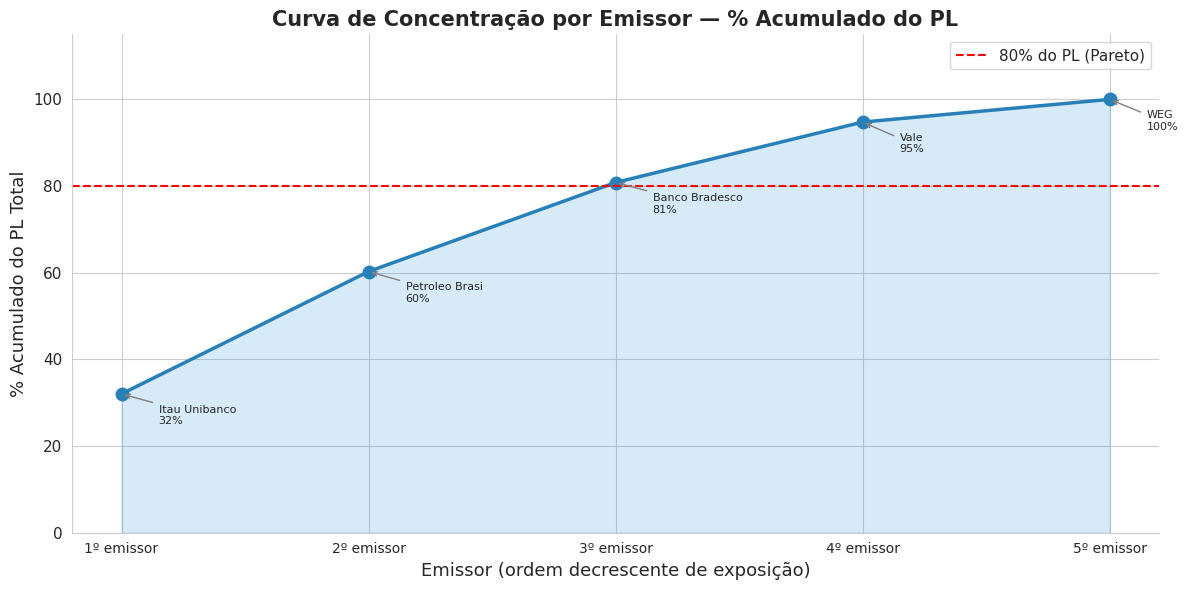

In [24]:
#curva concetração 
fig, ax = plt.subplots(figsize=(12, 6))

x = list(range(1, len(por_emissor) + 1))
ax.fill_between(x, por_emissor['% acum'], alpha=0.2, color='#3498db')
ax.plot(x, por_emissor['% acum'], 'o-', color='#2980b9', linewidth=2.5, markersize=9)
ax.axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='80% do PL (Pareto)')

for xi, yi, nome in zip(x, por_emissor['% acum'], nomes_curtos_emit):
    ax.annotate(f'{nome[:14]}\n{yi:.0f}%', xy=(xi, yi),
                xytext=(xi + 0.15, yi - 7), fontsize=8,
                arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax.set_xticks(x)
ax.set_xticklabels([f'{i}º emissor' for i in x], fontsize=10)
ax.set_ylim(0, 115)
ax.set_title('Curva de Concentração por Emissor — % Acumulado do PL', fontsize=15, fontweight='bold')
ax.set_xlabel('Emissor (ordem decrescente de exposição)')
ax.set_ylabel('% Acumulado do PL Total')
ax.legend(fontsize=11)
sns.despine()

plt.tight_layout()
plt.show()

---
## 8. Dashboard Executivo Final

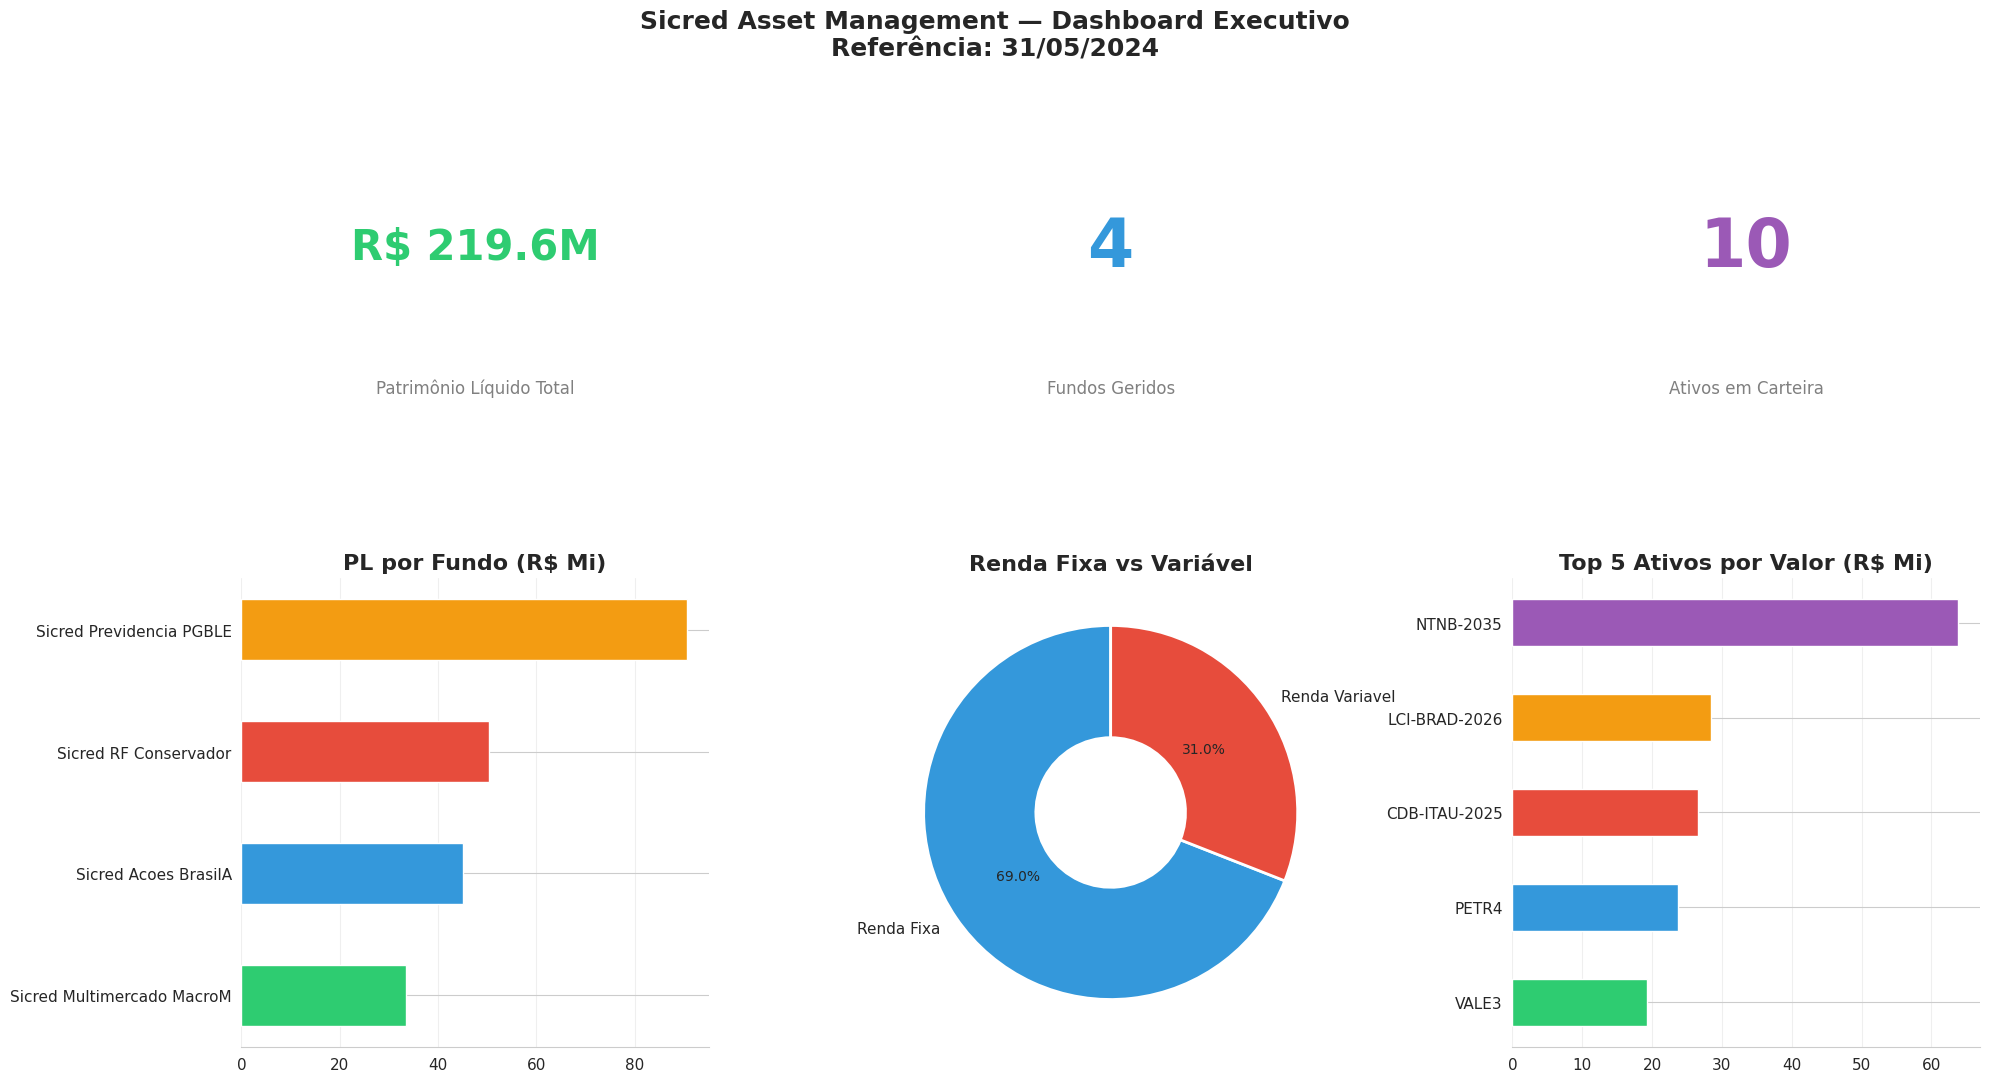

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Sicred Asset Management — Dashboard Executivo\nReferência: 31/05/2024',
             fontsize=18, fontweight='bold')

# Card PL Total
ax = axes[0, 0]
ax.text(0.5, 0.62, f'R$ {df["valor_financeiro"].sum()/1e6:.1f}M',
        ha='center', va='center', fontsize=30, fontweight='bold',
        color='#2ecc71', transform=ax.transAxes)
ax.text(0.5, 0.32, 'Patrimônio Líquido Total',
        ha='center', va='center', fontsize=12, color='gray', transform=ax.transAxes)
ax.axis('off')
ax.set_facecolor('#f8f9fa')

# Card Fundos
ax = axes[0, 1]
ax.text(0.5, 0.62, str(df['nome_fundo'].nunique()),
        ha='center', va='center', fontsize=48, fontweight='bold',
        color='#3498db', transform=ax.transAxes)
ax.text(0.5, 0.32, 'Fundos Geridos',
        ha='center', va='center', fontsize=12, color='gray', transform=ax.transAxes)
ax.axis('off')
ax.set_facecolor('#f8f9fa')

# Card Ativos
ax = axes[0, 2]
ax.text(0.5, 0.62, str(df['codigo_ativo'].nunique()),
        ha='center', va='center', fontsize=48, fontweight='bold',
        color='#9b59b6', transform=ax.transAxes)
ax.text(0.5, 0.32, 'Ativos em Carteira',
        ha='center', va='center', fontsize=12, color='gray', transform=ax.transAxes)
ax.axis('off')
ax.set_facecolor('#f8f9fa')

# PL por fundo
ax = axes[1, 0]
pl_f = df.groupby('nome_fundo')['valor_financeiro'].sum().sort_values()
nomes_f = [nome_curto(n) for n in pl_f.index]
ax.barh(nomes_f, pl_f.values / 1e6, color=CORES[:len(pl_f)], height=0.5)
ax.set_title('PL por Fundo (R$ Mi)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
sns.despine(ax=ax, left=True)

# Renda Fixa vs Variável
ax = axes[1, 1]
rv_rf = df.groupby('classe_ativo')['valor_financeiro'].sum()
ax.pie(rv_rf.values, labels=rv_rf.index, autopct='%1.1f%%',
       colors=[CORES_CLASSE.get(c, '#95a5a6') for c in rv_rf.index],
       startangle=90, wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2))
ax.set_title('Renda Fixa vs Variável', fontweight='bold')

# Top 5 ativos
ax = axes[1, 2]
top5 = df.groupby('codigo_ativo')['valor_financeiro'].sum().nlargest(5).sort_values()
ax.barh(top5.index, top5.values / 1e6, color=CORES[:5], height=0.5)
ax.set_title('Top 5 Ativos por Valor (R$ Mi)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
sns.despine(ax=ax, left=True)

plt.tight_layout()
plt.show()

---
## 9. Conclusões

- O **PL total** consolidado de todos os fundos representa uma carteira diversificada entre renda fixa e variável
- O fundo com maior concentração em renda fixa é o **RF Conservador**, com exposição predominante em títulos públicos
- O **Tesouro Nacional** é o emissor com maior exposição total, seguido de emissores privados com rating investment grade
- A curva de concentração mostra que os **2 primeiros emissores** respondem por mais de 60% do PL total
- Os ativos de **renda variável** apresentaram maior volatilidade no período simulado, enquanto renda fixa manteve trajetória estável